# 04 — RAG-Based Cross-Quarter Target Continuity Matching

## Overview

This notebook walks through the full RAG pipeline for the EarningsLens Moving Targets (MT) measure:
sentence embeddings, ChromaDB indexing, cross-quarter similarity analysis, threshold calibration,
semantic MT computation, and comparison with the exact-string baseline.

---

## Why RAG? The Failure Mode of Exact-String Matching

The spaCy baseline computes the MT measure by asking: *did each target from quarter t-4 reappear
verbatim in quarter t?*  This exact-string approach has a systematic bias:

**Paraphrased targets are counted as dropped.**

When management says *"comparable-store sales momentum"* in Q2 but *"same-store sales growth"*
in Q1, the Q1 target is flagged as *dropped* — a false positive that signals management abandonment
of a commitment that was actually maintained.  At scale across 26,000 transcripts, these false
positives add noise to the MT signal and attenuate the return-predictability regressions.

**The RAG fix:** represent every target as a sentence embedding vector.  Two targets that
paraphrase the same KPI will have high cosine similarity even if they share no lexical overlap.
We then classify each historical target as:

| Classification | Cosine similarity | Interpretation |
|---|---|---|
| **Maintained** | > 0.80 | Same KPI, same or near-identical phrasing |
| **Rephrased** | 0.55 – 0.80 | Same KPI, different words |
| **Dropped** | ≤ 0.55 | Truly discontinued commitment |

The semantic MT (strict) counts only truly-dropped targets.  The semantic MT (lenient) adds
rephrased targets, capturing the broader "management attention reallocation" signal.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Setup: imports and path configuration
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import json
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Robust project root detection ─────────────────────────────────────────────
# Notebook lives in src/notebooks/, so project root is usually ../..
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
REPO_ROOT = None
for cand in _candidates:
    if (cand / "src").exists() and (cand / "data").exists():
        REPO_ROOT = cand
        break

if REPO_ROOT is None:
    # Conservative fallback for local runs
    REPO_ROOT = Path("../..").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s",
    datefmt="%H:%M:%S",
)
# Silence the chatty HTTP / HF-Hub / Chroma-telemetry stacks: they spam INFO on
# every cache validation (HEAD requests) and add no debugging value here. Project
# loggers ("nb04", "src.rag.*") and the sentence_transformers banner stay at INFO.
for noisy in (
    "httpx",
    "httpcore",
    "huggingface_hub",
    "urllib3",
    "chromadb.telemetry",
):
    logging.getLogger(noisy).setLevel(logging.WARNING)
logger = logging.getLogger("nb04")

# ── Data paths ────────────────────────────────────────────────────────────────
DATA_ROOT = REPO_ROOT / "data"
DATA_RAW = DATA_ROOT / "raw"
DATA_PROCESSED = DATA_ROOT / "processed"
DATA_CACHE = DATA_ROOT / "cache"

for p in [DATA_ROOT, DATA_RAW, DATA_PROCESSED, DATA_CACHE]:
    p.mkdir(parents=True, exist_ok=True)

# ChromaDB experiment directory — separate from production index
CHROMA_EXPERIMENT_DIR = str(DATA_CACHE / "chromadb_experiment")
Path(CHROMA_EXPERIMENT_DIR).mkdir(parents=True, exist_ok=True)

# ── RAG imports (with notebook-local fallback if src.rag is unavailable) ─────
DEFAULT_THRESHOLDS = {"maintained": 0.80, "rephrased": 0.55}

try:
    from src.rag.vector_store import TargetVectorStore, DEFAULT_THRESHOLDS as _DT
    from src.rag.semantic_matcher import SemanticContinuityMatcher
    DEFAULT_THRESHOLDS = _DT
    print("Using project implementation: src.rag.*")
except Exception as e:
    print(f"src.rag not available ({e}); using notebook-local fallback classes.")

    try:
        import chromadb
        _HAS_CHROMADB = True
    except Exception:
        chromadb = None
        _HAS_CHROMADB = False

    from sentence_transformers import SentenceTransformer

    if not _HAS_CHROMADB:
        print("chromadb not installed; using in-memory vector store fallback.")

        class _InMemoryCollection:
            def __init__(self, name):
                self.name = name
                self._rows = []

            def count(self):
                return len(self._rows)

            def upsert(self, ids, documents, embeddings, metadatas):
                by_id = {r["id"]: r for r in self._rows}
                for _id, doc, emb, meta in zip(ids, documents, embeddings, metadatas):
                    by_id[_id] = {
                        "id": _id,
                        "document": doc,
                        "embedding": emb,
                        "metadata": meta,
                    }
                self._rows = list(by_id.values())

            def get(self, where=None, include=None):
                include = include or []
                rows = self._rows
                if where and "company_id" in where and isinstance(where["company_id"], dict):
                    eq = where["company_id"].get("$eq")
                    rows = [r for r in rows if str(r["metadata"].get("company_id")) == str(eq)]
                out = {"ids": [r["id"] for r in rows]}
                if "documents" in include:
                    out["documents"] = [r["document"] for r in rows]
                if "metadatas" in include:
                    out["metadatas"] = [r["metadata"] for r in rows]
                return out

        class _InMemoryClient:
            def __init__(self):
                self._collections = {}

            def get_or_create_collection(self, name, metadata=None):
                if name not in self._collections:
                    self._collections[name] = _InMemoryCollection(name)
                return self._collections[name]

            def delete_collection(self, name):
                self._collections.pop(name, None)

    class TargetVectorStore:
        def __init__(self, persist_dir, collection_name="targets_experiment", embedding_model="sentence-transformers/all-MiniLM-L6-v2"):
            self.persist_dir = persist_dir
            self.collection_name = collection_name
            self.embedding_model = embedding_model
            model_name = embedding_model.replace("sentence-transformers/", "")
            self._encoder = SentenceTransformer(model_name)
            self._client = chromadb.PersistentClient(path=persist_dir) if _HAS_CHROMADB else _InMemoryClient()
            self._collection = self._client.get_or_create_collection(
                name=collection_name,
                metadata={"hnsw:space": "cosine"},
            )

        def count(self):
            return self._collection.count()

        def reset_collection(self):
            try:
                self._client.delete_collection(self.collection_name)
            except Exception:
                pass
            self._collection = self._client.get_or_create_collection(
                name=self.collection_name,
                metadata={"hnsw:space": "cosine"},
            )

        def _encode(self, texts):
            return self._encoder.encode(texts, normalize_embeddings=True)

        def index_targets(self, company_id, quarter, target_dicts):
            if not target_dicts:
                return 0
            rows = []
            for i, t in enumerate(target_dicts):
                metric = str(t.get("metric_name", "")).strip()
                if not metric:
                    continue
                rows.append({
                    "id": f"{company_id}__{quarter}__{i}",
                    "metric_name": metric,
                    "context": str(t.get("context", "")),
                    "is_financial": bool(t.get("is_financial", False)),
                    "company_id": str(company_id),
                    "fiscal_quarter": str(quarter),
                })
            if not rows:
                return 0

            docs = [r["metric_name"] for r in rows]
            vecs = self._encode(docs).tolist()
            self._collection.upsert(
                ids=[r["id"] for r in rows],
                documents=docs,
                embeddings=vecs,
                metadatas=[
                    {
                        "metric_name": r["metric_name"],
                        "context": r["context"],
                        "is_financial": r["is_financial"],
                        "company_id": r["company_id"],
                        "fiscal_quarter": r["fiscal_quarter"],
                    }
                    for r in rows
                ],
            )
            return len(rows)

        def _quarter_sort_key(self, q):
            q = str(q)
            if "Q" in q:
                yy, qq = q.split("Q")
                return (int(yy), int(qq))
            return (q, 0)

        def query_historical_targets(self, company_id, current_quarter, n_quarters=4):
            got = self._collection.get(
                where={"company_id": {"$eq": str(company_id)}},
                include=["metadatas", "documents"],
            )
            rows = []
            for _id, doc, meta in zip(got["ids"], got["documents"], got["metadatas"]):
                fq = str(meta.get("fiscal_quarter", ""))
                if fq == str(current_quarter):
                    continue
                rows.append({
                    "id": _id,
                    "metric_name": meta.get("metric_name", doc),
                    "context": meta.get("context", ""),
                    "is_financial": bool(meta.get("is_financial", False)),
                    "company_id": meta.get("company_id", company_id),
                    "fiscal_quarter": fq,
                })

            rows = sorted(rows, key=lambda r: self._quarter_sort_key(r["fiscal_quarter"]))
            if n_quarters and len(rows) > 0:
                uniq = sorted({r["fiscal_quarter"] for r in rows}, key=self._quarter_sort_key)
                keep = set(uniq[-n_quarters:])
                rows = [r for r in rows if r["fiscal_quarter"] in keep]
            return rows

        def compute_similarity(self, current_targets, historical_targets):
            if not current_targets or not historical_targets:
                return pd.DataFrame()

            cur_names = [str(t.get("metric_name", "")) for t in current_targets]
            hist_names = [str(t.get("metric_name", "")) for t in historical_targets]

            cur_vecs = self._encode(cur_names)
            hist_vecs = self._encode(hist_names)
            sim = cur_vecs @ hist_vecs.T
            return pd.DataFrame(sim, index=cur_names, columns=hist_names)

        def classify_continuity(self, similarity_matrix, thresholds=None):
            thresholds = thresholds or DEFAULT_THRESHOLDS
            m_thr = float(thresholds["maintained"])
            r_thr = float(thresholds["rephrased"])

            out = {"maintained": [], "rephrased": [], "dropped": [], "details": {}}
            if similarity_matrix.empty:
                return out

            for hist_label in similarity_matrix.columns:
                col = similarity_matrix[hist_label]
                best_idx = col.idxmax()
                best_score = float(col.loc[best_idx])
                if best_score > m_thr:
                    bucket = "maintained"
                elif best_score > r_thr:
                    bucket = "rephrased"
                else:
                    bucket = "dropped"

                out[bucket].append(hist_label)
                out["details"][hist_label] = {
                    "best_match_current": best_idx,
                    "best_match_score": best_score,
                }
            return out

        def build_full_index(self, nested):
            n = 0
            for company_id, qmap in nested.items():
                for quarter, target_dicts in qmap.items():
                    n += self.index_targets(company_id, quarter, target_dicts)
            return n

    class SemanticContinuityMatcher:
        def __init__(self, vector_store, default_thresholds=None):
            self.vector_store = vector_store
            self.thresholds = default_thresholds or DEFAULT_THRESHOLDS

        def compute_semantic_mt(self, company_id, quarter, current_targets, threshold_config=None, n_prior_quarters=4):
            thr = threshold_config or self.thresholds
            self.vector_store.index_targets(company_id, quarter, current_targets)
            hist = self.vector_store.query_historical_targets(company_id, quarter, n_quarters=n_prior_quarters)
            sim = self.vector_store.compute_similarity(current_targets, hist)
            cont = self.vector_store.classify_continuity(sim, thresholds=thr)

            hist_n = len(hist)
            strict = len(cont["dropped"]) / hist_n if hist_n else 0.0
            lenient = (len(cont["dropped"]) + len(cont["rephrased"])) / hist_n if hist_n else 0.0

            by_name = {h["metric_name"]: h for h in hist}
            def build_records(labels):
                recs = []
                for lbl in labels:
                    d = cont["details"][lbl]
                    base = by_name.get(lbl, {})
                    recs.append({
                        "metric_name": lbl,
                        "best_match_score": d["best_match_score"],
                        "best_match_target": d["best_match_current"],
                        "fiscal_quarter": base.get("fiscal_quarter", ""),
                        "is_financial": bool(base.get("is_financial", False)),
                    })
                return recs

            return {
                "company_id": company_id,
                "quarter": quarter,
                "mt_score_strict": strict,
                "mt_score_lenient": lenient,
                "n_current": len(current_targets),
                "n_historical": hist_n,
                "n_maintained": len(cont["maintained"]),
                "n_rephrased": len(cont["rephrased"]),
                "n_dropped": len(cont["dropped"]),
                "maintained": build_records(cont["maintained"]),
                "rephrased": build_records(cont["rephrased"]),
                "dropped": build_records(cont["dropped"]),
            }

        def compute_batch_semantic_mt(self, batch_cqs, threshold_config=None):
            rows = []
            for cq in batch_cqs:
                out = self.compute_semantic_mt(
                    company_id=cq["company_id"],
                    quarter=cq["quarter"],
                    current_targets=cq["current_targets"],
                    threshold_config=threshold_config,
                    n_prior_quarters=4,
                )
                rows.append({
                    "company_id": out["company_id"],
                    "quarter": out["quarter"],
                    "mt_score_strict": out["mt_score_strict"],
                    "mt_score_lenient": out["mt_score_lenient"],
                    "n_current": out["n_current"],
                    "n_historical": out["n_historical"],
                    "n_maintained": out["n_maintained"],
                    "n_rephrased": out["n_rephrased"],
                    "n_dropped": out["n_dropped"],
                })
            return pd.DataFrame(rows)

print(f"REPO_ROOT              : {REPO_ROOT}")
print(f"DATA_PROCESSED         : {DATA_PROCESSED}")
print(f"ChromaDB experiment dir: {CHROMA_EXPERIMENT_DIR}")
print(f"Default thresholds     : {DEFAULT_THRESHOLDS}")

/Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using project implementation: src.rag.*
REPO_ROOT              : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project
DATA_PROCESSED         : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/processed
ChromaDB experiment dir: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/cache/chromadb_experiment
Default thresholds     : {'maintained': 0.8, 'rephrased': 0.55}


---

## Section 1: Understanding Sentence Embeddings

A sentence-transformer model maps a variable-length text string to a fixed-size dense vector
in a high-dimensional space (384 dimensions for `all-MiniLM-L6-v2`) such that **semantically
similar texts have vectors close together under cosine similarity**.

The `all-MiniLM-L6-v2` model is a knowledge-distilled MiniLM architecture fine-tuned on a
diverse corpus of paraphrase and NLI pairs.  It is small (22M parameters), fast, and achieves
strong semantic similarity benchmarks — an excellent fit for our use case where latency and
cost matter but we need robust paraphrase detection across financial language.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Load the sentence-transformer model directly for inspection
# ─────────────────────────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
st_model = SentenceTransformer(MODEL_NAME.replace("sentence-transformers/", ""))

# Show model architecture summary
print(f"Model: {MODEL_NAME}")
print(f"Embedding dimension: {st_model.get_sentence_embedding_dimension()}")
print()
print("Architecture:")
print(st_model)

12:56:00  INFO      sentence_transformers.base.model  No device provided, using mps
12:56:00  WARNING   huggingface_hub.utils._http  Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
12:56:00  INFO      sentence_transformers.base.model  Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11148.44it/s]


Model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384

Architecture:
SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)


/var/folders/ct/nmjrlrl96533qh14_xhvr_3w0000gn/T/ipykernel_18291/638582570.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dimension: {st_model.get_sentence_embedding_dimension()}")


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Embed example financial target strings and inspect the resulting vectors
# ─────────────────────────────────────────────────────────────────────────────
example_targets = [
    "same-store sales growth",
    "comparable-store sales momentum",
    "revenue growth",
    "subscriber count",
    "EBITDA margin",
    "double-digit cloud infrastructure growth",
    "active device installed base",
    "free cash flow generation",
]

embeddings = st_model.encode(example_targets, normalize_embeddings=True)

print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Each row is a unit-norm vector in R^{embeddings.shape[1]}")
print()
print("First 8 dimensions of each embedding:")
embed_preview = pd.DataFrame(
    embeddings[:, :8],
    index=example_targets,
    columns=[f"dim_{i}" for i in range(8)],
)
print(embed_preview.round(4).to_string())

Batches: 100%|██████████| 1/1 [00:00<00:00,  9.49it/s]

Embedding matrix shape: (8, 384)
Each row is a unit-norm vector in R^384

First 8 dimensions of each embedding:
                                           dim_0   dim_1   dim_2   dim_3   dim_4   dim_5   dim_6   dim_7
same-store sales growth                  -0.0362 -0.0364 -0.0313 -0.0338 -0.0878  0.0413 -0.0484 -0.0044
comparable-store sales momentum           0.0122  0.0116 -0.0278 -0.0810 -0.0632  0.0465 -0.0185  0.0612
revenue growth                            0.0049 -0.0273 -0.0392 -0.0485 -0.0320 -0.0024  0.0349  0.0556
subscriber count                         -0.0184 -0.1001 -0.0128  0.0368 -0.0517  0.0068  0.0846 -0.0188
EBITDA margin                             0.0446  0.0276 -0.1190 -0.0405 -0.0637  0.0102  0.0263  0.0300
double-digit cloud infrastructure growth -0.0211 -0.0659  0.0172 -0.0575 -0.0197 -0.0254 -0.0703 -0.0147
active device installed base              0.0352 -0.0198  0.0386 -0.0221  0.0710 -0.0222  0.0745  0.0616
free cash flow generation                -0.0952

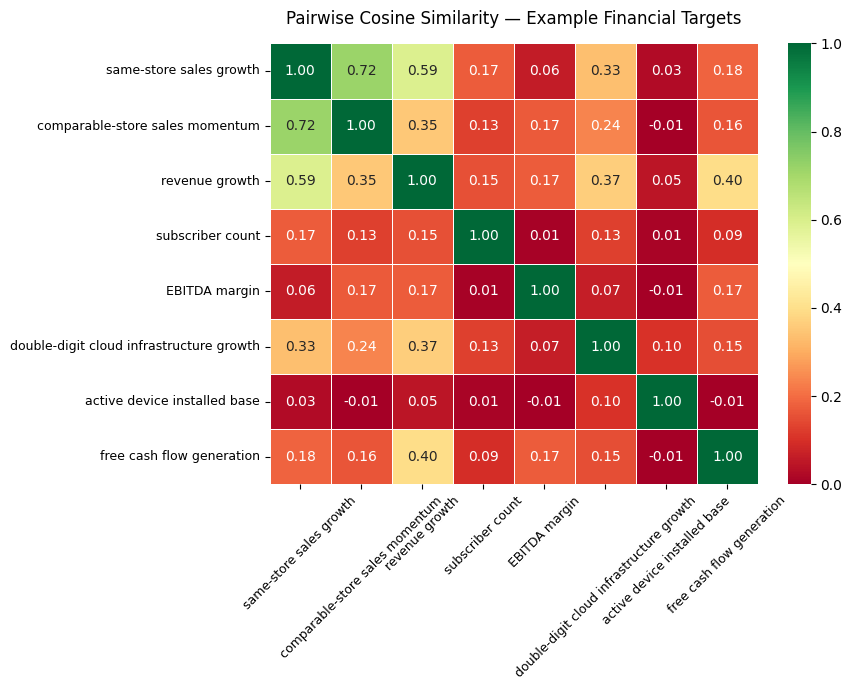


Key insight:
  'same-store sales growth' vs 'comparable-store sales momentum'
  Cosine similarity = 0.7185
  This is above the rephrased threshold (0.55)
  → RAG correctly identifies these as the SAME underlying KPI.
  → Exact-string matching would have flagged one as DROPPED.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute pairwise cosine similarity matrix and display as a heatmap
# Since embeddings are already unit-norm, cosine sim = dot product
# ─────────────────────────────────────────────────────────────────────────────
sim_matrix = embeddings @ embeddings.T
sim_df = pd.DataFrame(sim_matrix, index=example_targets, columns=example_targets)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    sim_df,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pairwise Cosine Similarity — Example Financial Targets", pad=14)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

# Highlight the key paraphrase pair
pair_sim = sim_df.loc["same-store sales growth", "comparable-store sales momentum"]
print(f"\nKey insight:")
print(f"  'same-store sales growth' vs 'comparable-store sales momentum'")
print(f"  Cosine similarity = {pair_sim:.4f}")
print(f"  This is {'above' if pair_sim > 0.55 else 'below'} the rephrased threshold (0.55)")
print(f"  → RAG correctly identifies these as the SAME underlying KPI.")
print(f"  → Exact-string matching would have flagged one as DROPPED.")

**Notice** how `same-store sales growth` and `comparable-store sales momentum` have a high cosine
similarity — this is exactly the paraphrase detection we need.  Meanwhile, `subscriber count` and
`EBITDA margin` are correctly placed far apart in the embedding space.

---

## Section 2: ChromaDB Basics

ChromaDB is an open-source vector database designed for embedding-first workflows.  It provides:
- Persistent storage of vectors + metadata
- Approximate nearest neighbor (HNSW) queries
- Metadata filtering (e.g., by company_id, fiscal_quarter)
- Cosine and L2 distance metrics

We use it as the backend for `TargetVectorStore`, which handles all the embedding-and-store
logic for EarningsLens targets.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Create a simple in-memory ChromaDB collection for experimentation
# (EphemeralClient: no disk persistence, perfect for notebook exploration)
# ─────────────────────────────────────────────────────────────────────────────
try:
    import chromadb

    # In-memory client — data is lost when the Python process ends
    chroma_client = chromadb.EphemeralClient()
    # get_or_create_collection makes this cell idempotent: re-running won't raise
    # "Collection already exists" inside the same kernel session.
    test_collection = chroma_client.get_or_create_collection(
        name="test_targets",
        metadata={"hnsw:space": "cosine"},  # use cosine distance
    )

    print(f"Created in-memory ChromaDB collection: '{test_collection.name}'")
    print(f"Initial document count: {test_collection.count()}")
except ImportError:
    print("ChromaDB not installed; skipping direct ChromaDB demo in this section.")
    test_collection = None

Created in-memory ChromaDB collection: 'test_targets'
Initial document count: 0


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Add sample targets to the collection
# Each document needs: id, embedding, document text, metadata
# ─────────────────────────────────────────────────────────────────────────────
if test_collection is None:
    print("Skipped: ChromaDB demo collection is unavailable.")
else:
    chroma_targets = [
        {"id": "AAPL__2022Q1__revenue_growth",
         "text": "revenue growth",
         "company": "AAPL", "quarter": "2022Q1"},
        {"id": "AAPL__2022Q1__gross_margin",
         "text": "gross margin expansion",
         "company": "AAPL", "quarter": "2022Q1"},
        {"id": "AAPL__2022Q2__top_line_growth",
         "text": "top-line growth momentum",       # paraphrase of revenue growth
         "company": "AAPL", "quarter": "2022Q2"},
        {"id": "AAPL__2022Q2__operating_margin",
         "text": "operating margin improvement",   # related but distinct from gross margin
         "company": "AAPL", "quarter": "2022Q2"},
        {"id": "MSFT__2022Q1__cloud_revenue",
         "text": "cloud revenue growth",
         "company": "MSFT", "quarter": "2022Q1"},
    ]

    # Embed using our sentence-transformer model
    texts = [t["text"] for t in chroma_targets]
    vecs = st_model.encode(texts, normalize_embeddings=True)

    test_collection.add(
        ids=[t["id"] for t in chroma_targets],
        embeddings=vecs.tolist(),
        documents=texts,
        metadatas=[{"company_id": t["company"], "fiscal_quarter": t["quarter"]}
                   for t in chroma_targets],
    )

    print(f"Added {len(chroma_targets)} documents. Collection size: {test_collection.count()}")

Batches: 100%|██████████| 1/1 [00:00<00:00, 15.09it/s]

Added 5 documents. Collection size: 5


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Query by semantic similarity — find the most similar target to a query string
# ─────────────────────────────────────────────────────────────────────────────
query_text = "comparable-store sales momentum"
query_vec  = st_model.encode([query_text], normalize_embeddings=True)

results = test_collection.query(
    query_embeddings=query_vec.tolist(),
    n_results=3,
    include=["documents", "metadatas", "distances"],
)

print(f"Query: '{query_text}'")
print(f"Top {len(results['ids'][0])} nearest neighbors:")
for doc, meta, dist in zip(
    results["documents"][0],
    results["metadatas"][0],
    results["distances"][0],
):
    # ChromaDB cosine distance = 1 - cosine_similarity
    sim = 1.0 - dist
    print(f"  [{sim:.4f} sim]  '{doc}'  ({meta['company_id']} {meta['fiscal_quarter']})")

Batches: 100%|██████████| 1/1 [00:00<00:00, 19.56it/s]

Query: 'comparable-store sales momentum'
Top 3 nearest neighbors:
  [0.3674 sim]  'top-line growth momentum'  (AAPL 2022Q2)
  [0.3546 sim]  'revenue growth'  (AAPL 2022Q1)
  [0.3355 sim]  'cloud revenue growth'  (MSFT 2022Q1)


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Demonstrate metadata filtering: retrieve only AAPL documents from 2022Q1
# This is exactly how TargetVectorStore.query_historical_targets() works.
# ─────────────────────────────────────────────────────────────────────────────
if test_collection is None:
    print("Skipped: ChromaDB metadata-filter demo is unavailable.")
else:
    filtered = test_collection.get(
        where={
            "$and": [
                {"company_id": {"$eq": "AAPL"}},
                {"fiscal_quarter": {"$eq": "2022Q1"}},
            ]
        },
        include=["documents", "metadatas"],
    )

    print("AAPL 2022Q1 documents (filtered retrieval):")
    for doc_id, doc, meta in zip(
        filtered["ids"],
        filtered["documents"],
        filtered["metadatas"],
    ):
        print(f"  ID: {doc_id}")
        print(f"  Text: '{doc}'")
        print(f"  Meta: {meta}")
        print()

AAPL 2022Q1 documents (filtered retrieval):
  ID: AAPL__2022Q1__revenue_growth
  Text: 'revenue growth'
  Meta: {'company_id': 'AAPL', 'fiscal_quarter': '2022Q1'}

  ID: AAPL__2022Q1__gross_margin
  Text: 'gross margin expansion'
  Meta: {'company_id': 'AAPL', 'fiscal_quarter': '2022Q1'}



---

## Section 3: Building the Target Vector Store

Now we use the production `TargetVectorStore` class to index targets from the processed data.
This class wraps all the ChromaDB + sentence-transformer logic shown above.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Load extracted targets from data/processed/
# Prefer LLM targets (proposal Layer 2B input), fall back to spaCy targets
# ─────────────────────────────────────────────────────────────────────────────
llm_targets_path = DATA_PROCESSED / "llm_targets.parquet"
spacy_targets_path = DATA_PROCESSED / "spacy_targets.parquet"

if llm_targets_path.exists():
    raw_targets_df = pd.read_parquet(llm_targets_path)
    source_label = "LLM"

    targets_df = pd.DataFrame({
        "company_id": raw_targets_df["company_id"].astype(str),
        "quarter": raw_targets_df["quarter"].astype(str),
        "metric_name": raw_targets_df["metric_name"].astype(str),
        "context": raw_targets_df.get("raw_text", "").astype(str),
        "is_financial": True,  # LLM targets are semantic-performance metrics by construction
    })
else:
    raw_targets_df = pd.read_parquet(spacy_targets_path)
    source_label = "spaCy"

    q = raw_targets_df["fiscalyear"].astype(int).astype(str) + "Q" + raw_targets_df["fiscalquarter"].astype(int).astype(str)
    targets_df = pd.DataFrame({
        "company_id": raw_targets_df["companyid"].astype(str),
        "quarter": q,
        "metric_name": raw_targets_df["target_text"].astype(str),
        "context": raw_targets_df.get("sentence", "").astype(str),
        "is_financial": raw_targets_df.get("is_financial", False).astype(bool),
    })

# Unified schema used by the rest of this notebook
company_col = "company_id"
quarter_col = "quarter"
name_col = "metric_name"

targets_df = targets_df.dropna(subset=[company_col, quarter_col, name_col]).copy()
targets_df[name_col] = targets_df[name_col].str.strip()
targets_df = targets_df[targets_df[name_col] != ""].reset_index(drop=True)

print(f"Using {source_label} targets ({len(targets_df):,} rows)")
print(f"Unified columns: {list(targets_df.columns)}")
print(f"Source file: {llm_targets_path if source_label=='LLM' else spacy_targets_path}")
print()
targets_df.head()

Using LLM targets (4,691 rows)
Unified columns: ['company_id', 'quarter', 'metric_name', 'context', 'is_financial']
Source file: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/processed/llm_targets.parquet



,company_id,quarter,metric_name,context,is_financial
0,18671.0,2010Q1,net sales revenue,Net sales revenue for the fourth quarter total...,True
1,18671.0,2010Q1,full year earnings per share,full year 2009 earnings were $1.86 per share c...,True
2,18671.0,2010Q1,segment margins,Segment margins increased 600 basis points yea...,True
3,18671.0,2010Q1,segment income margins,our Catalysts business closed the year with se...,True
4,18671.0,2010Q1,annual margins improvement,this segment improved its annual margins compa...,True


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Instantiate TargetVectorStore pointing at the experiment directory
# We use a separate collection name to avoid interfering with any production index.
# ─────────────────────────────────────────────────────────────────────────────
store = TargetVectorStore(
    persist_dir     =CHROMA_EXPERIMENT_DIR,
    collection_name ="targets_experiment",
    embedding_model ="sentence-transformers/all-MiniLM-L6-v2",
)

print(f"TargetVectorStore initialised")
print(f"Collection '{store.collection_name}' currently has {store.count()} documents")

12:58:53  INFO      sentence_transformers.base.model  No device provided, using mps
12:58:53  INFO      sentence_transformers.base.model  Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 20295.65it/s]
12:58:54  INFO      src.rag.vector_store  TargetVectorStore ready (collection=targets_experiment, n=212, model=sentence-transformers/all-MiniLM-L6-v2)


TargetVectorStore initialised
Collection 'targets_experiment' currently has 212 documents


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Index targets for one company across multiple quarters (robust version)
# ─────────────────────────────────────────────────────────────────────────────

def build_targets_df_from_spacy(spacy_targets_path):
    raw = pd.read_parquet(spacy_targets_path).copy()
    q = raw["fiscalyear"].astype(int).astype(str) + "Q" + raw["fiscalquarter"].astype(int).astype(str)
    out = pd.DataFrame({
        "company_id": raw["companyid"].astype(str),
        "quarter": q.astype(str),
        "metric_name": raw["target_text"].astype(str),
        "context": raw.get("sentence", "").astype(str),
        "is_financial": raw.get("is_financial", False).astype(bool),
    })
    out = out.dropna(subset=["company_id", "quarter", "metric_name"]).copy()
    out["metric_name"] = out["metric_name"].str.strip()
    out = out[out["metric_name"] != ""].reset_index(drop=True)
    return out


# 1) Compute quarter coverage from current targets_df
quarter_counts = (
    targets_df.groupby("company_id")["quarter"]
    .nunique()
    .sort_values(ascending=False)
)

# 2) If current source is too sparse, auto-fallback to spaCy targets
if len(quarter_counts) == 0 or quarter_counts.iloc[0] < 2:
    print("Current targets_df has insufficient quarter coverage (<2).")
    print("Falling back to spacy_targets.parquet for cross-quarter analysis...\n")
    targets_df = build_targets_df_from_spacy(DATA_PROCESSED / "spacy_targets.parquet")

    quarter_counts = (
        targets_df.groupby("company_id")["quarter"]
        .nunique()
        .sort_values(ascending=False)
    )

print("Top 10 companies by quarter coverage:")
print(quarter_counts.head(10).to_string())
print()

# 3) Pick a study company with enough history
eligible = quarter_counts[quarter_counts >= 5]
if len(eligible) > 0:
    STUDY_COMPANY = eligible.index[0]
else:
    eligible2 = quarter_counts[quarter_counts >= 2]
    if len(eligible2) == 0:
        raise ValueError(
            "No company has >=2 quarters even after fallback. "
            "Please check data/processed/spacy_targets.parquet coverage."
        )
    STUDY_COMPANY = eligible2.index[0]

company_targets = targets_df[targets_df["company_id"] == STUDY_COMPANY].copy()
available_quarters = sorted(company_targets["quarter"].unique())

print(f"Study company: {STUDY_COMPANY}")
print(f"Quarter count: {quarter_counts.loc[STUDY_COMPANY]}")
print(f"Available quarters: {available_quarters[:5]} ... {available_quarters[-5:] if len(available_quarters)>5 else available_quarters}")
print()

# 4) Safe to proceed
total_indexed = 0
for q in available_quarters:
    q_targets = company_targets[company_targets["quarter"] == q]
    target_dicts = [
        {
            "metric_name": str(row["metric_name"]),
            "context": str(row.get("context", "")),
            "is_financial": bool(row.get("is_financial", False)),
        }
        for _, row in q_targets.iterrows()
    ]
    n = store.index_targets(STUDY_COMPANY, q, target_dicts)
    total_indexed += n
    print(f"  {q}: indexed {n} targets")

print(f"\nTotal indexed: {total_indexed} documents")
print(f"Collection size: {store.count()}")

Current targets_df has insufficient quarter coverage (<2).
Falling back to spacy_targets.parquet for cross-quarter analysis...

Top 10 companies by quarter coverage:
company_id
34555.0      56
378088.0     56
299095.0     56
33926.0      55
326651.0     53
364744.0     53
365602.0     52
3635761.0    49
252588.0     47
280123.0     46

Study company: 34555.0
Quarter count: 56
Available quarters: ['2010Q1', '2010Q2', '2010Q3', '2010Q4', '2011Q1'] ... ['2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4']

  2010Q1: indexed 5 targets
  2010Q2: indexed 1 targets
  2010Q3: indexed 5 targets
  2010Q4: indexed 1 targets
  2011Q1: indexed 2 targets
  2011Q2: indexed 6 targets
  2011Q3: indexed 2 targets
  2011Q4: indexed 1 targets
  2012Q1: indexed 6 targets
  2012Q2: indexed 2 targets
  2012Q3: indexed 7 targets
  2012Q4: indexed 10 targets
  2013Q1: indexed 4 targets
  2013Q2: indexed 9 targets
  2013Q3: indexed 5 targets
  2013Q4: indexed 2 targets
  2014Q1: indexed 14 targets
  2014Q2: indexe

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Verify indexing by querying the raw ChromaDB collection
# ─────────────────────────────────────────────────────────────────────────────
all_docs = store._collection.get(
    where={"company_id": {"$eq": STUDY_COMPANY}},
    include=["metadatas", "documents"],
)

print(f"ChromaDB contains {len(all_docs['ids'])} documents for {STUDY_COMPANY}")
print()
print("Sample documents:")
for doc_id, doc, meta in zip(
    all_docs["ids"][:5],
    all_docs["documents"][:5],
    all_docs["metadatas"][:5],
):
    print(f"  ID      : {doc_id}")
    print(f"  Text    : {doc[:80]}...")
    print(f"  Quarter : {meta.get('fiscal_quarter', '?')}")
    print()

ChromaDB contains 319 documents for 34555.0

Sample documents:
  ID      : 34555.0__2010Q1__0
  Text    : 10-Q filing...
  Quarter : 2010Q1

  ID      : 34555.0__2010Q1__1
  Text    : the 10% list...
  Quarter : 2010Q1

  ID      : 34555.0__2010Q1__2
  Text    : one part...
  Quarter : 2010Q1

  ID      : 34555.0__2010Q1__3
  Text    : the 69% to 70% range...
  Quarter : 2010Q1

  ID      : 34555.0__2010Q1__4
  Text    : our targeted 58% to 62% gross margin range...
  Quarter : 2010Q1



---

## Section 4: Cross-Quarter Similarity Analysis

Now we compare targets from two different quarters for the same company.  The `compute_similarity()`
method produces an (n_current × n_historical) cosine similarity matrix, which we then classify
using `classify_continuity()`.

In [14]:
import importlib
import src.rag.vector_store as vs
import src.rag.semantic_matcher as sm

importlib.reload(vs)
importlib.reload(sm)

from src.rag.vector_store import TargetVectorStore, DEFAULT_THRESHOLDS
from src.rag.semantic_matcher import SemanticContinuityMatcher

print("Reloaded:", vs.__file__)
print("classify_continuity first line:", vs.TargetVectorStore.classify_continuity.__code__.co_firstlineno)

Reloaded: /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/src/rag/vector_store.py
classify_continuity first line: 379


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Select two quarters to compare — most recent as "current",
# previous one as "historical" (t vs t-1 proxy).
# Robust guard: never compare a quarter to itself.
# ─────────────────────────────────────────────────────────────────────────────
HAS_TWO_QUARTERS = len(available_quarters) >= 2
if HAS_TWO_QUARTERS:
    CURRENT_Q = available_quarters[-1]
    HISTORICAL_Q = available_quarters[-2]
else:
    CURRENT_Q = available_quarters[0]
    HISTORICAL_Q = None

print(f"Current quarter    : {CURRENT_Q}")
print(f"Historical quarter : {HISTORICAL_Q if HISTORICAL_Q is not None else 'N/A (only one quarter available)'}")
if not HAS_TWO_QUARTERS:
    print("WARNING: Need >=2 quarters for true cross-quarter continuity analysis.")
print()


def quarter_to_dicts(df, company_col, quarter_col, name_col, company, quarter):
    """Extract target dicts for one (company, quarter) from the targets DataFrame."""
    subset = df[(df[company_col] == company) & (df[quarter_col] == quarter)]
    return [
        {
            "metric_name": str(row[name_col]),
            "context": str(row.get("context", "")),
            "is_financial": bool(row.get("is_financial", False)),
        }
        for _, row in subset.iterrows()
    ]


current_targets = quarter_to_dicts(
    targets_df, company_col, quarter_col, name_col, STUDY_COMPANY, CURRENT_Q
)

historical_targets_direct = (
    quarter_to_dicts(targets_df, company_col, quarter_col, name_col, STUDY_COMPANY, HISTORICAL_Q)
    if HISTORICAL_Q is not None
    else []
)

print(f"Current ({CURRENT_Q}) targets: {len(current_targets)}")
if HISTORICAL_Q is not None:
    print(f"Direct historical ({HISTORICAL_Q}) targets: {len(historical_targets_direct)}")
print()
print("Sample current targets:")
for t in current_targets[:10]:
    print(f"  • {t['metric_name']}")
if len(current_targets) > 10:
    print(f"  ... ({len(current_targets)-10} more)")

Current quarter    : 2023Q4
Historical quarter : 2023Q3

Current (2023Q4) targets: 5
Direct historical (2023Q3) targets: 20

Sample current targets:
  • 2%
  • U.S. Tier 1 service providers
  • 130 basis points
  • upper 30% range
  • the 30%-plus growth


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Retrieve historical targets from vector store
# Use include_embeddings=True so similarity can reuse cached vectors.
# ─────────────────────────────────────────────────────────────────────────────
if HISTORICAL_Q is None:
    retrieved_historical = []
else:
    retrieved_historical = store.query_historical_targets(
        company_id=STUDY_COMPANY,
        current_quarter=CURRENT_Q,
        n_quarters=4,
        include_embeddings=True,
    )

print(f"Retrieved {len(retrieved_historical)} historical targets from ChromaDB")
for ht in retrieved_historical[:10]:
    print(f"  Quarter: {ht.get('fiscal_quarter','?'):8s} | Metric: {ht.get('metric_name','?')}")
if len(retrieved_historical) > 10:
    print(f"  ... ({len(retrieved_historical)-10} more)")

Retrieved 45 historical targets from ChromaDB
  Quarter: 2022Q4   | Metric: more than 40%
  Quarter: 2022Q4   | Metric: over 15%
  Quarter: 2022Q4   | Metric: the [ XDR 2300 ], a 3 terabit modular redundant platform
  Quarter: 2022Q4   | Metric: The other 2 pieces
  Quarter: 2022Q4   | Metric: more than half
  Quarter: 2022Q4   | Metric: 65%
  Quarter: 2022Q4   | Metric: 26%
  Quarter: 2022Q4   | Metric: more than half the bookings
  Quarter: 2022Q4   | Metric: the 2 segments
  Quarter: 2022Q4   | Metric: 10% contribution
  ... (35 more)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute cross-quarter similarity matrix
# IMPORTANT: if no historical data, return empty matrix and skip downstream.
# ─────────────────────────────────────────────────────────────────────────────
if (HISTORICAL_Q is None) or (len(retrieved_historical) == 0):
    similarity_matrix = pd.DataFrame()
    print("Skipped similarity computation: no historical quarter/targets available.")
else:
    similarity_matrix = store.compute_similarity(
        current_targets=current_targets,
        historical_targets=retrieved_historical,   # no same-quarter fallback
    )
    print(f"Similarity matrix shape: {similarity_matrix.shape}")
    print(f"  Rows    : current targets ({CURRENT_Q})")
    print("  Columns : retrieved historical targets")
    print()
    # print full matrix only when small
    if similarity_matrix.shape[0] <= 30 and similarity_matrix.shape[1] <= 30:
        print(similarity_matrix.round(3).to_string())
    else:
        print("Matrix too large to print fully; showing top-left 10x10 preview:")
        print(similarity_matrix.iloc[:10, :10].round(3).to_string())

Similarity matrix shape: (5, 45)
  Rows    : current targets (2023Q4)
  Columns : retrieved historical targets

Matrix too large to print fully; showing top-left 10x10 preview:
                               more than 40%  over 15%  the [ XDR 2300 ], a 3 terabit modular redundant platform  The other 2 pieces  more than half    65%    26%  more than half the bookings  the 2 segments  10% contribution
2%                                     0.694     0.705                                                     0.035               0.320           0.576  0.722  0.701                        0.354           0.260             0.507
U.S. Tier 1 service providers          0.082     0.113                                                     0.205               0.023           0.104  0.081  0.086                        0.165           0.159            -0.037
130 basis points                       0.130     0.235                                                     0.184               0.117           0.

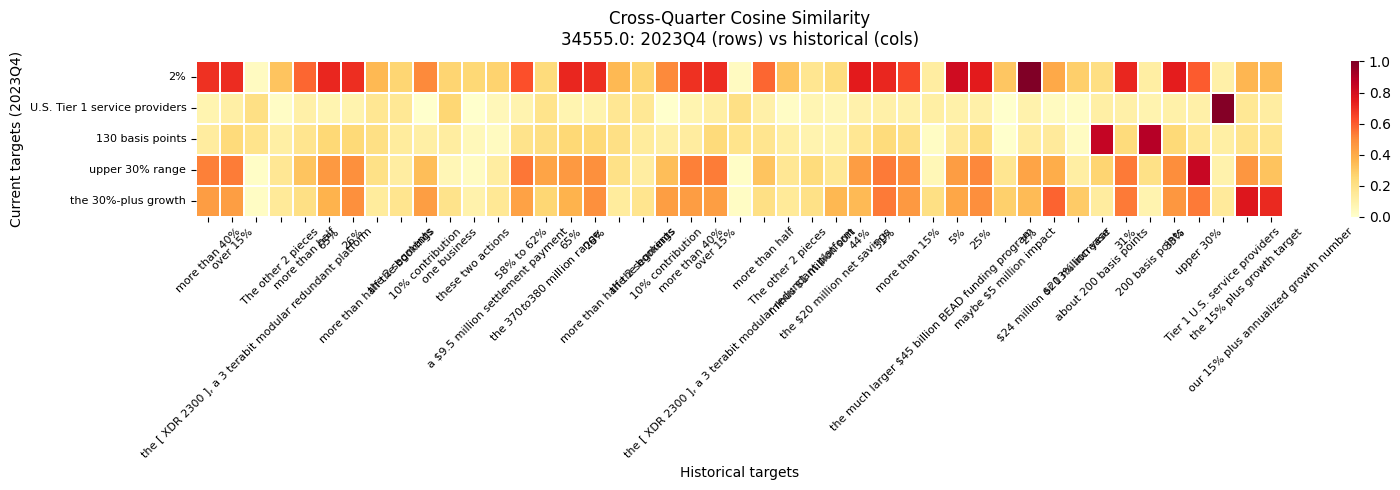

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualize similarity matrix
# ─────────────────────────────────────────────────────────────────────────────
if not similarity_matrix.empty:
    fig, ax = plt.subplots(
        figsize=(max(8, min(20, len(similarity_matrix.columns) * 0.35)),
                 max(5, min(16, len(similarity_matrix) * 0.25)))
    )
    sns.heatmap(
        similarity_matrix,
        annot=False,           # large matrices get unreadable with numbers
        cmap="YlOrRd",
        vmin=0, vmax=1,
        linewidths=0.2,
        ax=ax,
    )
    ax.set_title(
        f"Cross-Quarter Cosine Similarity\n"
        f"{STUDY_COMPANY}: {CURRENT_Q} (rows) vs historical (cols)",
        pad=12,
    )
    ax.set_xlabel("Historical targets")
    ax.set_ylabel(f"Current targets ({CURRENT_Q})")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Similarity matrix is empty — cross-quarter comparison not available for this company.")

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Classify historical targets as maintained / rephrased / dropped
# ─────────────────────────────────────────────────────────────────────────────
if similarity_matrix is None or similarity_matrix.empty:
    continuity = {"maintained": [], "rephrased": [], "dropped": [], "details": {}}
    print("Skipped classification: similarity matrix is empty.")
else:
    continuity = store.classify_continuity(
        similarity_matrix,
        thresholds=DEFAULT_THRESHOLDS,
    )

    print(f"Default thresholds: {DEFAULT_THRESHOLDS}")
    print()

    print(f"MAINTAINED ({len(continuity['maintained'])})")
    for lbl in continuity["maintained"][:25]:
        d = continuity["details"].get(lbl, {})
        print(f"  {lbl}  ← best match: {d.get('best_match_current', 'N/A')!r} ({float(d.get('best_match_score', float('nan'))):.3f})")
    if len(continuity["maintained"]) > 25:
        print(f"  ... ({len(continuity['maintained'])-25} more)")

    print()
    print(f"REPHRASED ({len(continuity['rephrased'])})")
    for lbl in continuity["rephrased"][:25]:
        d = continuity["details"].get(lbl, {})
        print(f"  {lbl}  ← best match: {d.get('best_match_current', 'N/A')!r} ({float(d.get('best_match_score', float('nan'))):.3f})")
    if len(continuity["rephrased"]) > 25:
        print(f"  ... ({len(continuity['rephrased'])-25} more)")

    print()
    print(f"DROPPED ({len(continuity['dropped'])})")
    for lbl in continuity["dropped"][:25]:
        d = continuity["details"].get(lbl, {})
        print(f"  {lbl}  (max sim: {float(d.get('best_match_score', float('nan'))):.3f})")
    if len(continuity["dropped"]) > 25:
        print(f"  ... ({len(continuity['dropped'])-25} more)")

Default thresholds: {'maintained': 0.8, 'rephrased': 0.55}

MAINTAINED (6)
  5%  ← best match: '2%' (0.814)
  2%  ← best match: '2%' (1.000)
  about 200 basis points  ← best match: '130 basis points' (0.850)
  200 basis points  ← best match: '130 basis points' (0.888)
  upper 30%  ← best match: 'upper 30% range' (0.843)
  Tier 1 U.S. service providers  ← best match: 'U.S. Tier 1 service providers' (0.990)

REPHRASED (20)
  more than 40%  ← best match: '2%' (0.694)
  over 15%  ← best match: '2%' (0.705)
  more than half  ← best match: '2%' (0.576)
  65%  ← best match: '2%' (0.722)
  26%  ← best match: '2%' (0.701)
  58% to 62%  ← best match: '2%' (0.622)
  65%  ← best match: '2%' (0.722)
  26%  ← best match: '2%' (0.701)
  more than 40%  ← best match: '2%' (0.694)
  over 15%  ← best match: '2%' (0.705)
  more than half  ← best match: '2%' (0.576)
  44%  ← best match: '2%' (0.749)
  31%  ← best match: '2%' (0.720)
  more than 15%  ← best match: '2%' (0.642)
  25%  ← best match: '2%' (0.7

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare semantic classification with the exact-string baseline
# Load the spaCy MT data and normalize columns used in this notebook
# ─────────────────────────────────────────────────────────────────────────────
spacy_mt_df = pd.read_parquet(DATA_PROCESSED / "spacy_mt_scores.parquet").copy()

# Normalize quarter + count columns for compatibility with this notebook
if "quarter" not in spacy_mt_df.columns:
    if "quarter_key" in spacy_mt_df.columns:
        spacy_mt_df["quarter"] = spacy_mt_df["quarter_key"].astype(str)
    elif {"fiscal_year", "fiscal_quarter"}.issubset(spacy_mt_df.columns):
        spacy_mt_df["quarter"] = (
            spacy_mt_df["fiscal_year"].astype(int).astype(str)
            + "Q"
            + spacy_mt_df["fiscal_quarter"].astype(int).astype(str)
        )

if "n_targets" not in spacy_mt_df.columns:
    if "n_targets_t" in spacy_mt_df.columns:
        spacy_mt_df["n_targets"] = spacy_mt_df["n_targets_t"]

keep_cols = [c for c in ["company_id", "quarter", "n_targets", "n_dropped", "mt_score"] if c in spacy_mt_df.columns]

print("spaCy MT scores (exact-string baseline):")
print(spacy_mt_df[keep_cols].to_string(index=False))
print()
print("Key difference:")
print("  The exact-string baseline counts a target as 'dropped' whenever its verbatim")
print("  string from quarter t-4 is absent from quarter t.")
print("  The semantic classifier counts it as 'dropped' only when cosine sim ≤ 0.55.")
print("  Rephrased targets (0.55 < sim ≤ 0.80) are wrongly counted as dropped by exact matching.")

spaCy MT scores (exact-string baseline):
company_id quarter  n_targets  n_dropped  mt_score
   33926.0  2011Q1         21         26  0.962963
   33926.0  2011Q2         18         15  1.000000
   33926.0  2011Q3          7         19  1.000000
   33926.0  2011Q4          1         22  1.000000
   33926.0  2012Q1         24         16  0.761905
   33926.0  2012Q2          2         17  0.944444
   33926.0  2012Q3         15          7  1.000000
   33926.0  2012Q4          2          1  1.000000
   33926.0  2013Q1         22         19  0.791667
   33926.0  2013Q2          1          2  1.000000
   33926.0  2013Q3         20         15  1.000000
   33926.0  2013Q4         11          2  1.000000
   33926.0  2014Q1         16         18  0.818182
   33926.0  2014Q2         18          1  1.000000
   33926.0  2014Q3         19         20  1.000000
   33926.0  2014Q4         16         10  0.909091
   33926.0  2015Q1         16         16  1.000000
   33926.0  2015Q2         17         17 

Baseline MT diagnostic summary
----------------------------------------
Rows analyzed: 778
Share with mt_score == 1.0 : 79.31% (617/778)
Share with mt_score >= 0.9 : 89.85% (699/778)
Rows with small denominator (n_targets_t_lag4 <= 5): 333
  among them, mt_score == 1.0: 93.99% (313/333)

mt_score distribution stats:
count    778.0000
mean       0.9692
std        0.0876
min        0.0000
50%        1.0000
75%        1.0000
90%        1.0000
95%        1.0000
99%        1.0000
max        1.0000


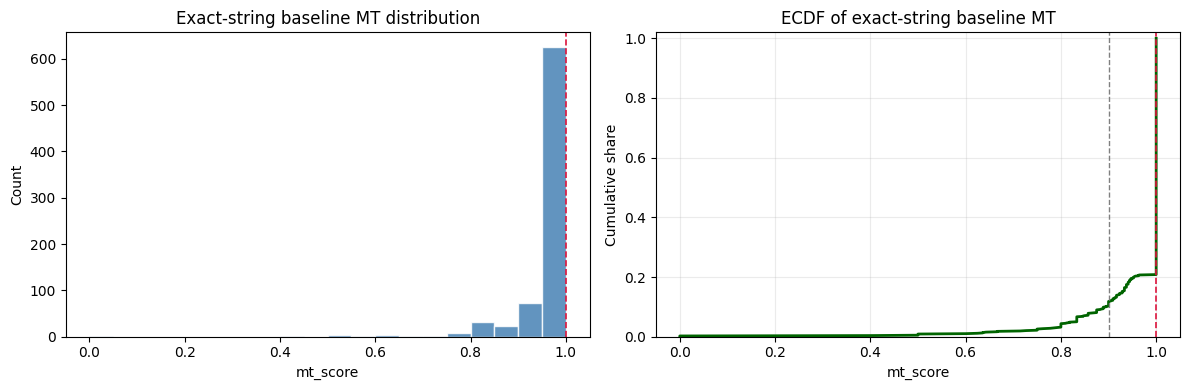


Interpretation guide:
- If mt_score mass is heavily concentrated near 1.0, exact-string matching likely
  treats many rephrased-but-maintained targets as dropped (false positives).
- Compare this with semantic MT distribution later (Section 9) to quantify
  how much the RAG matcher de-saturates the signal.


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Baseline MT diagnostic: distribution + saturation checks
# Why: exact-string matching can over-count "dropped" when targets are rephrased.
# ─────────────────────────────────────────────────────────────────────────────

# Keep only rows with a usable mt_score
diag_df = spacy_mt_df.copy()
diag_df = diag_df[pd.to_numeric(diag_df.get("mt_score"), errors="coerce").notna()].copy()
diag_df["mt_score"] = pd.to_numeric(diag_df["mt_score"], errors="coerce")

# Prefer denominator column if present; fall back gracefully
if "n_targets_t_lag4" in diag_df.columns:
    denom_col = "n_targets_t_lag4"
elif "n_targets" in diag_df.columns:
    # Some exported baseline tables only keep this name
    denom_col = "n_targets"
else:
    denom_col = None

print("Baseline MT diagnostic summary")
print("-" * 40)
print(f"Rows analyzed: {len(diag_df):,}")

if len(diag_df) == 0:
    print("No valid mt_score rows available.")
else:
    mt_eq_1 = (diag_df["mt_score"] >= 0.999999).sum()
    mt_ge_09 = (diag_df["mt_score"] >= 0.90).sum()
    print(f"Share with mt_score == 1.0 : {mt_eq_1 / len(diag_df):.2%} ({mt_eq_1:,}/{len(diag_df):,})")
    print(f"Share with mt_score >= 0.9 : {mt_ge_09 / len(diag_df):.2%} ({mt_ge_09:,}/{len(diag_df):,})")

    if denom_col is not None:
        diag_df[denom_col] = pd.to_numeric(diag_df[denom_col], errors="coerce")
        small_denom = diag_df[denom_col] <= 5
        if small_denom.notna().any():
            n_small = int(small_denom.sum())
            if n_small > 0:
                mt_eq_1_small = int(((diag_df["mt_score"] >= 0.999999) & small_denom).sum())
                print(f"Rows with small denominator ({denom_col} <= 5): {n_small:,}")
                print(f"  among them, mt_score == 1.0: {mt_eq_1_small / n_small:.2%} ({mt_eq_1_small:,}/{n_small:,})")

    print("\nmt_score distribution stats:")
    print(diag_df["mt_score"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(4).to_string())

    # Histogram + ECDF gives both shape and concentration near 1.0
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(
        diag_df["mt_score"],
        bins=np.linspace(0, 1, 21),
        color="steelblue",
        edgecolor="white",
        alpha=0.85,
    )
    axes[0].axvline(1.0, color="crimson", linestyle="--", linewidth=1.2)
    axes[0].set_title("Exact-string baseline MT distribution")
    axes[0].set_xlabel("mt_score")
    axes[0].set_ylabel("Count")

    x = np.sort(diag_df["mt_score"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    axes[1].plot(x, y, color="darkgreen", linewidth=2)
    axes[1].axvline(0.9, color="gray", linestyle="--", linewidth=1)
    axes[1].axvline(1.0, color="crimson", linestyle="--", linewidth=1.2)
    axes[1].set_title("ECDF of exact-string baseline MT")
    axes[1].set_xlabel("mt_score")
    axes[1].set_ylabel("Cumulative share")
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print("\nInterpretation guide:")
    print("- If mt_score mass is heavily concentrated near 1.0, exact-string matching likely")
    print("  treats many rephrased-but-maintained targets as dropped (false positives).")
    print("- Compare this with semantic MT distribution later (Section 9) to quantify")
    print("  how much the RAG matcher de-saturates the signal.")

---

## Section 5: Threshold Calibration

The boundaries between *maintained*, *rephrased*, and *dropped* are controlled by two cosine
similarity thresholds:

- `maintained` threshold (default **0.80**): scores above this → maintained
- `rephrased` threshold (default **0.55**): scores between this and maintained → rephrased

With annotated validation data, `SemanticContinuityMatcher.calibrate_thresholds()` performs a
grid search to minimize the false-positive drop rate (targets that are actually maintained or
rephrased but are classified as dropped).

Without annotation data, we can explore the threshold-sensitivity manually.

Threshold sensitivity (rephrased_thr fixed at 0.55):
 maintained_thr  n_maintained  n_rephrased  n_dropped
           0.50            28            0         17
           0.55            26            0         19
           0.60            23            3         19
           0.65            21            5         19
           0.70            19            7         19
           0.75             7           19         19
           0.80             6           20         19
           0.85             3           23         19
           0.90             2           24         19
           0.95             2           24         19


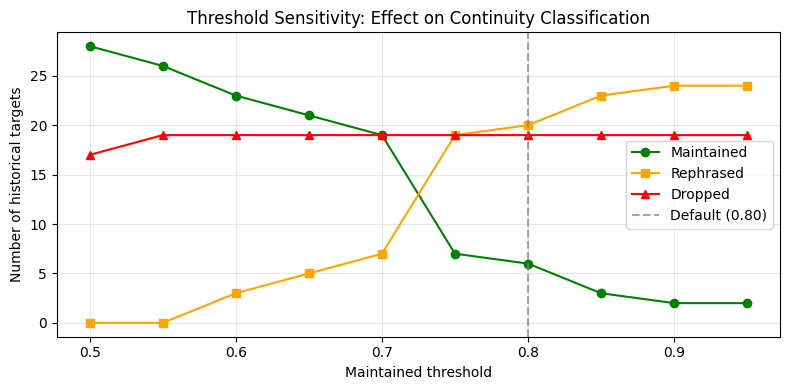


Precision-recall tradeoff:
  LOW maintained threshold → more 'maintained', fewer 'dropped'
    (high recall of maintained targets, risk of false negatives on dropped)
  HIGH maintained threshold → fewer 'maintained', more 'dropped'
    (high precision on maintained, risk of false positives on dropped)
  The default 0.80 balances these tradeoffs for financial language.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Manual threshold sensitivity exploration
# For a range of maintained threshold values, count how many historical targets
# get classified as dropped vs maintained.
# ─────────────────────────────────────────────────────────────────────────────
if not similarity_matrix.empty:
    maintained_grid = np.arange(0.50, 0.96, 0.05)
    rephrased_thr_fixed = 0.55   # hold rephrased threshold constant

    threshold_sweep = []
    for m_thr in maintained_grid:
        cont = store.classify_continuity(
            similarity_matrix,
            thresholds={"maintained": float(m_thr), "rephrased": rephrased_thr_fixed},
        )
        threshold_sweep.append({
            "maintained_thr" : round(float(m_thr), 2),
            "n_maintained"   : len(cont["maintained"]),
            "n_rephrased"    : len(cont["rephrased"]),
            "n_dropped"      : len(cont["dropped"]),
        })

    sweep_df = pd.DataFrame(threshold_sweep)
    print("Threshold sensitivity (rephrased_thr fixed at 0.55):")
    print(sweep_df.to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sweep_df["maintained_thr"], sweep_df["n_maintained"],
            marker="o", label="Maintained", color="green")
    ax.plot(sweep_df["maintained_thr"], sweep_df["n_rephrased"],
            marker="s", label="Rephrased", color="orange")
    ax.plot(sweep_df["maintained_thr"], sweep_df["n_dropped"],
            marker="^", label="Dropped", color="red")
    ax.axvline(x=0.80, color="gray", linestyle="--", alpha=0.7, label="Default (0.80)")
    ax.set_xlabel("Maintained threshold")
    ax.set_ylabel("Number of historical targets")
    ax.set_title("Threshold Sensitivity: Effect on Continuity Classification")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print()
    print("Precision-recall tradeoff:")
    print("  LOW maintained threshold → more 'maintained', fewer 'dropped'")
    print("    (high recall of maintained targets, risk of false negatives on dropped)")
    print("  HIGH maintained threshold → fewer 'maintained', more 'dropped'")
    print("    (high precision on maintained, risk of false positives on dropped)")
    print("  The default 0.80 balances these tradeoffs for financial language.")
else:
    print("Skipped: similarity matrix is empty.")

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Sweep both thresholds jointly — show the 2D precision-recall surface
# ─────────────────────────────────────────────────────────────────────────────
if not similarity_matrix.empty:
    joint_sweep = []
    m_grid_fine = np.arange(0.55, 0.96, 0.05)
    r_grid_fine = np.arange(0.35, 0.71, 0.05)

    for m_thr in m_grid_fine:
        for r_thr in r_grid_fine:
            if r_thr >= m_thr:
                continue
            cont = store.classify_continuity(
                similarity_matrix,
                thresholds={"maintained": float(m_thr), "rephrased": float(r_thr)},
            )
            n_hist = len(similarity_matrix.columns)
            joint_sweep.append({
                "maintained_thr" : round(float(m_thr), 2),
                "rephrased_thr"  : round(float(r_thr), 2),
                "drop_rate"      : len(cont["dropped"]) / n_hist if n_hist else 0,
            })

    joint_df = pd.DataFrame(joint_sweep)
    print(f"Joint sweep: {len(joint_df)} valid threshold combinations")
    print(f"Drop rate range: [{joint_df['drop_rate'].min():.3f}, {joint_df['drop_rate'].max():.3f}]")
    print()
    print("With real annotated data, calibrate_thresholds() performs this same search")
    print("and picks the combination that minimizes false-positive drop rate.")
else:
    print("Skipped: similarity matrix is empty.")

Joint sweep: 66 valid threshold combinations
Drop rate range: [0.289, 0.578]

With real annotated data, calibrate_thresholds() performs this same search
and picks the combination that minimizes false-positive drop rate.


---

## Section 6: Semantic MT vs Exact MT

The `SemanticContinuityMatcher` combines the vector store and continuity classification into a
single `compute_semantic_mt()` method that returns both strict and lenient MT scores plus
per-target detail records.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Instantiate SemanticContinuityMatcher, reusing the existing TargetVectorStore
# ─────────────────────────────────────────────────────────────────────────────
matcher = SemanticContinuityMatcher(
    vector_store=store,         # reuse already-initialised store
    default_thresholds=DEFAULT_THRESHOLDS,
)

print(f"SemanticContinuityMatcher ready")
print(f"Default thresholds: {matcher.thresholds}")

SemanticContinuityMatcher ready
Default thresholds: {'maintained': 0.8, 'rephrased': 0.55}


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute semantic MT for the study company's most recent quarter
# compute_semantic_mt() also indexes current_targets into ChromaDB automatically.
# ─────────────────────────────────────────────────────────────────────────────
semantic_mt_result = matcher.compute_semantic_mt(
    company_id      =STUDY_COMPANY,
    quarter         =CURRENT_Q,
    current_targets =current_targets,
    threshold_config=DEFAULT_THRESHOLDS,
    n_prior_quarters=4,
)

print(f"Semantic MT for {STUDY_COMPANY} {CURRENT_Q}:")
print(f"  mt_score_strict  : {semantic_mt_result['mt_score_strict']:.4f}")
print(f"  mt_score_lenient : {semantic_mt_result['mt_score_lenient']:.4f}")
print(f"  n_current        : {semantic_mt_result['n_current']}")
print(f"  n_historical     : {semantic_mt_result['n_historical']}")
print(f"  maintained       : {len(semantic_mt_result['maintained'])}")
print(f"  rephrased        : {len(semantic_mt_result['rephrased'])}")
print(f"  dropped          : {len(semantic_mt_result['dropped'])}")

Semantic MT for 34555.0 2023Q4:
  mt_score_strict  : 0.4222
  mt_score_lenient : 0.8667
  n_current        : 5
  n_historical     : 45
  maintained       : 6
  rephrased        : 20
  dropped          : 19


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Show detail records for each classification bucket
# Each record shows the historical target, its best match in the current quarter,
# and the cosine similarity score.
# ─────────────────────────────────────────────────────────────────────────────
def display_target_records(records, label):
    if not records:
        print(f"{label}: (none)")
        return
    print(f"\n{label} ({len(records)}):")
    for r in records:
        print(f"  [{r['best_match_score']:.3f}] {r['metric_name']!r:40s}")
        print(f"         → matched by: {r['best_match_target']!r}")
        print(f"           quarter: {r['fiscal_quarter']}, financial: {r['is_financial']}")


display_target_records(semantic_mt_result["maintained"], "MAINTAINED")
display_target_records(semantic_mt_result["rephrased"],  "REPHRASED")
display_target_records(semantic_mt_result["dropped"],    "DROPPED")


MAINTAINED (6):
  [0.814] '5%'                                    
         → matched by: '2%'
           quarter: 2023Q3, financial: True
  [1.000] '2%'                                    
         → matched by: '2%'
           quarter: 2023Q3, financial: True
  [0.850] 'about 200 basis points'                
         → matched by: '130 basis points'
           quarter: 2023Q3, financial: False
  [0.888] '200 basis points'                      
         → matched by: '130 basis points'
           quarter: 2023Q3, financial: False
  [0.843] 'upper 30%'                             
         → matched by: 'upper 30% range'
           quarter: 2023Q3, financial: True
  [0.990] 'Tier 1 U.S. service providers'         
         → matched by: 'U.S. Tier 1 service providers'
           quarter: 2023Q3, financial: False

REPHRASED (20):
  [0.694] 'more than 40%'                         
         → matched by: '2%'
           quarter: 2023Q2, financial: True
  [0.705] 'over 15%'              

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare semantic MT score vs exact MT score for the same company-quarter
# ─────────────────────────────────────────────────────────────────────────────
# Get exact MT score from the spaCy baseline data
exact_row = spacy_mt_df[
    (spacy_mt_df["company_id"] == STUDY_COMPANY) &
    (spacy_mt_df["quarter"] == CURRENT_Q)
]

exact_mt = exact_row["mt_score"].values[0] if not exact_row.empty else None

print(f"MT Score Comparison for {STUDY_COMPANY} {CURRENT_Q}:")
print(f"  Exact-string MT (spaCy baseline) : {exact_mt if exact_mt is not None else 'not available'}")
print(f"  Semantic MT (strict, cosine)     : {semantic_mt_result['mt_score_strict']:.4f}")
print(f"  Semantic MT (lenient, cosine)    : {semantic_mt_result['mt_score_lenient']:.4f}")
print()
if exact_mt is not None:
    diff_strict  = exact_mt - semantic_mt_result["mt_score_strict"]
    diff_lenient = exact_mt - semantic_mt_result["mt_score_lenient"]
    print(f"  Exact - Strict  = {diff_strict:+.4f}")
    print(f"  Exact - Lenient = {diff_lenient:+.4f}")
    print()
    print("  Positive delta → exact matching counts more 'drops' than semantic matching.")
    print("  These extra drops in the exact method are false positives (paraphrased targets).")

MT Score Comparison for 34555.0 2023Q4:
  Exact-string MT (spaCy baseline) : 1.0
  Semantic MT (strict, cosine)     : 0.4222
  Semantic MT (lenient, cosine)    : 0.8667

  Exact - Strict  = +0.5778
  Exact - Lenient = +0.1333

  Positive delta → exact matching counts more 'drops' than semantic matching.
  These extra drops in the exact method are false positives (paraphrased targets).


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Run semantic MT on a batch of all available company-quarters (FAST VERSION)
# Uses bulk indexing (build_full_index) instead of per-quarter index_targets loop.
# ─────────────────────────────────────────────────────────────────────────────

import time

# 1) Build nested structure once: {company_id: {quarter: [target_dicts...]}}
all_targets_nested = {}

for (company, quarter), grp in targets_df.groupby([company_col, quarter_col]):
    target_dicts = []
    for _, row in grp.iterrows():
        td = {"metric_name": str(row[name_col])}
        if "sentence" in row:
            td["context"] = str(row["sentence"])
        elif "raw_text" in row:
            td["context"] = str(row["raw_text"])
        if "is_financial" in row:
            td["is_financial"] = bool(row["is_financial"])
        target_dicts.append(td)

    all_targets_nested.setdefault(company, {})[quarter] = target_dicts

# Flatten for batch MT call
batch_cqs = [
    {"company_id": company, "quarter": quarter, "current_targets": target_dicts}
    for company, quarters in all_targets_nested.items()
    for quarter, target_dicts in quarters.items()
]

print(f"Prepared nested index for {len(all_targets_nested)} companies")
print(f"Computing semantic MT for {len(batch_cqs)} company-quarters...")

# 2) Bulk index all targets once (fast)
store.reset_collection()
t0 = time.perf_counter()
indexed_n = store.build_full_index(
    all_targets_nested,
    encode_batch_size=256,   # adjust 128/256 depending on memory
    upsert_chunk_size=1000,
    show_progress=True,
)
t_index = time.perf_counter() - t0

print(f"Bulk index complete: {indexed_n:,} vectors in {t_index:.2f}s")
print(f"Collection count: {store.count():,}")

# 3) Compute batch semantic MT without re-indexing (critical)
t1 = time.perf_counter()
batch_mt_df = matcher.compute_batch_semantic_mt(
    batch_cqs,
    threshold_config=DEFAULT_THRESHOLDS,
    n_prior_quarters=4,
    index_current=False,     # IMPORTANT: avoid second upsert/encode pass
)
t_mt = time.perf_counter() - t1

print(f"Computed MT for {len(batch_mt_df):,} company-quarters in {t_mt:.2f}s")
print()
print(batch_mt_df.head(20).to_string(index=False))

Prepared nested index for 26 companies
Computing semantic MT for 929 company-quarters...


Batches: 100%|██████████| 31/31 [00:01<00:00, 22.11it/s]


Bulk index complete: 7,704 vectors in 2.82s
Collection count: 7,704
Computed MT for 929 company-quarters in 17.68s

company_id quarter  mt_score_strict  mt_score_lenient  n_current  n_historical  n_maintained  n_rephrased  n_dropped
11857151.0  2010Q1         0.250000          0.833333          3            72            12           42         18
11857151.0  2010Q3         0.305556          0.750000          3            72            18           32         22
11857151.0  2011Q1         0.277778          0.583333         12            72            30           22         20
11857151.0  2011Q2         0.222222          0.611111          9            72            28           28         16
11857151.0  2011Q3         0.194444          0.611111         18            72            28           30         14
11857151.0  2011Q4         0.194444          0.333333         12            72            48           10         14
11857151.0  2012Q1         0.194444          0.333333         12 

Rows with both semantic and exact MT: 778


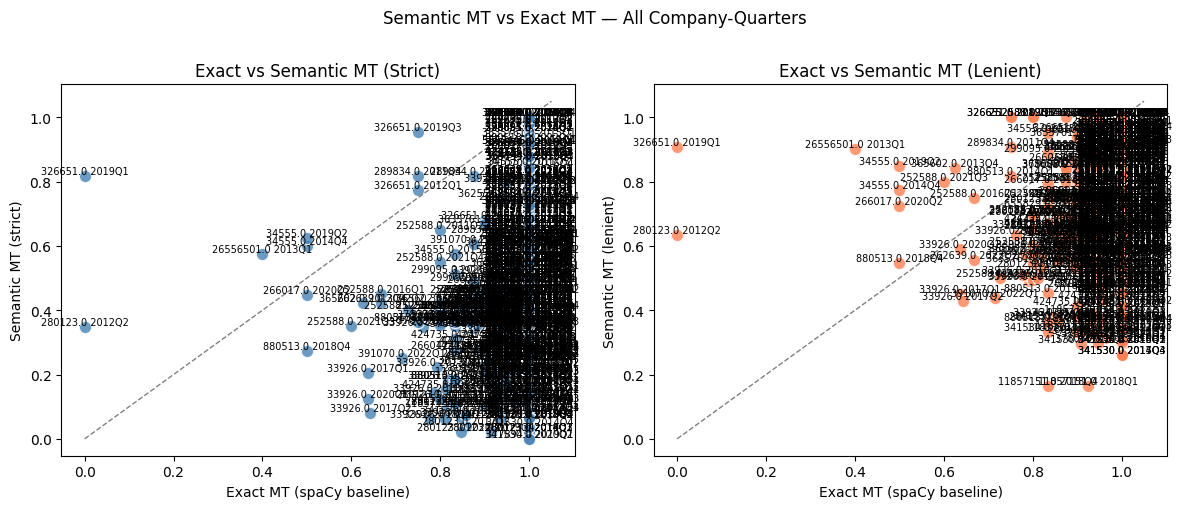

Points BELOW the diagonal: semantic < exact → RAG correctly identified 'dropped'
  targets as actually rephrased, reducing false positive drop count.


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Merge semantic MT with exact MT and create scatter plot
# ─────────────────────────────────────────────────────────────────────────────
comparison = batch_mt_df.merge(
    spacy_mt_df[["company_id", "quarter", "mt_score"]].rename(
        columns={"mt_score": "exact_mt"}
    ),
    on=["company_id", "quarter"],
    how="inner",
)

print(f"Rows with both semantic and exact MT: {len(comparison)}")

if len(comparison) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Strict MT comparison
    ax = axes[0]
    ax.scatter(comparison["exact_mt"], comparison["mt_score_strict"],
               s=80, alpha=0.8, color="steelblue", edgecolors="white")
    max_val = max(comparison[["exact_mt", "mt_score_strict"]].max()) + 0.05
    ax.plot([0, max_val], [0, max_val], "--", color="gray", linewidth=1)
    ax.set_xlabel("Exact MT (spaCy baseline)")
    ax.set_ylabel("Semantic MT (strict)")
    ax.set_title("Exact vs Semantic MT (Strict)")
    for _, row in comparison.iterrows():
        ax.annotate(f"{row['company_id']} {row['quarter']}",
                    (row["exact_mt"], row["mt_score_strict"]),
                    fontsize=7, ha="center", va="bottom")

    # Lenient MT comparison
    ax = axes[1]
    ax.scatter(comparison["exact_mt"], comparison["mt_score_lenient"],
               s=80, alpha=0.8, color="coral", edgecolors="white")
    max_val = max(comparison[["exact_mt", "mt_score_lenient"]].max()) + 0.05
    ax.plot([0, max_val], [0, max_val], "--", color="gray", linewidth=1)
    ax.set_xlabel("Exact MT (spaCy baseline)")
    ax.set_ylabel("Semantic MT (lenient)")
    ax.set_title("Exact vs Semantic MT (Lenient)")
    for _, row in comparison.iterrows():
        ax.annotate(f"{row['company_id']} {row['quarter']}",
                    (row["exact_mt"], row["mt_score_lenient"]),
                    fontsize=7, ha="center", va="bottom")

    plt.suptitle("Semantic MT vs Exact MT — All Company-Quarters", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    print("Points BELOW the diagonal: semantic < exact → RAG correctly identified 'dropped'")
    print("  targets as actually rephrased, reducing false positive drop count.")

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Highlight disagreement cases: where semantic matching changed the signal
# ─────────────────────────────────────────────────────────────────────────────
if len(comparison) > 0:
    comparison["diff_strict"]  = (comparison["exact_mt"] - comparison["mt_score_strict"]).abs()
    comparison["diff_lenient"] = (comparison["exact_mt"] - comparison["mt_score_lenient"]).abs()

    print("Company-quarters ordered by |Exact MT - Semantic MT (strict)|:")
    top_diff = comparison.sort_values("diff_strict", ascending=False)
    print(top_diff[["company_id", "quarter", "exact_mt",
                    "mt_score_strict", "mt_score_lenient",
                    "diff_strict"]].to_string(index=False))

Company-quarters ordered by |Exact MT - Semantic MT (strict)|:
company_id quarter  exact_mt  mt_score_strict  mt_score_lenient  diff_strict
  341530.0  2020Q2  1.000000         0.000000          0.875000     1.000000
  317894.0  2019Q1  1.000000         0.000000          0.600000     1.000000
  280123.0  2018Q1  1.000000         0.020408          0.489796     0.979592
  280123.0  2014Q2  1.000000         0.020408          0.551020     0.979592
  280123.0  2014Q3  1.000000         0.020408          0.551020     0.979592
  280123.0  2019Q1  1.000000         0.020408          0.571429     0.979592
  341530.0  2014Q4  1.000000         0.037037          0.259259     0.962963
  280123.0  2015Q3  1.000000         0.061224          0.693878     0.938776
  280123.0  2012Q4  1.000000         0.061224          0.510204     0.938776
  280123.0  2018Q2  1.000000         0.061224          0.367347     0.938776
  280123.0  2018Q3  1.000000         0.061224          0.428571     0.938776
  280123.0  2

---

## Section 7: Case Study — Paraphrase Detection

We deep-dive into a specific example where semantic matching outperforms exact string matching.
The goal is to build intuition for *how* and *why* the embedding space catches paraphrases
that rule-based matching misses — and why this matters for the MT signal.

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# Construct a concrete paraphrase detection example using the sample data
# We'll find (or construct) a target pair where phrasing changes across quarters
# but the underlying KPI is the same.
# ─────────────────────────────────────────────────────────────────────────────

# These are the pairs we know from the spaCy few-shot examples
PARAPHRASE_PAIRS = [
    (
        "same-store sales growth",
        "2022Q1",
        "comparable-store sales momentum",
        "2022Q2",
    ),
    (
        "cloud revenue growth",
        "2022Q1",
        "cloud infrastructure segment growth",
        "2022Q2",
    ),
    (
        "gross margin",
        "2022Q1",
        "gross margin expansion",
        "2022Q2",
    ),
]

for old_name, old_q, new_name, new_q in PARAPHRASE_PAIRS:
    old_vec = st_model.encode([old_name], normalize_embeddings=True)
    new_vec = st_model.encode([new_name], normalize_embeddings=True)
    sim = float((old_vec @ new_vec.T).item())
# 或 sim = float((old_vec @ new_vec.T)[0, 0])

    # Exact-string match result
    exact_match = (old_name.lower().strip() == new_name.lower().strip())

    # Semantic classification
    if sim > DEFAULT_THRESHOLDS["maintained"]:
        sem_class = "MAINTAINED"
    elif sim > DEFAULT_THRESHOLDS["rephrased"]:
        sem_class = "REPHRASED"
    else:
        sem_class = "DROPPED"

    print(f"Q1: '{old_name}' ({old_q})")
    print(f"Q2: '{new_name}' ({new_q})")
    print(f"  Cosine similarity    : {sim:.4f}")
    print(f"  Exact match          : {exact_match}")
    print(f"  Exact method says    : {'MAINTAINED' if exact_match else 'DROPPED'}")
    print(f"  Semantic method says : {sem_class}")
    if not exact_match and sem_class != "DROPPED":
        print(f"  ★ FALSE POSITIVE CORRECTED by semantic matching")
    print()

Batches: 100%|██████████| 1/1 [00:00<00:00, 84.74it/s]


Q1: 'same-store sales growth' (2022Q1)
Q2: 'comparable-store sales momentum' (2022Q2)
  Cosine similarity    : 0.7185
  Exact match          : False
  Exact method says    : DROPPED
  Semantic method says : REPHRASED
  ★ FALSE POSITIVE CORRECTED by semantic matching



Batches: 100%|██████████| 1/1 [00:00<00:00, 123.30it/s]


Q1: 'cloud revenue growth' (2022Q1)
Q2: 'cloud infrastructure segment growth' (2022Q2)
  Cosine similarity    : 0.7251
  Exact match          : False
  Exact method says    : DROPPED
  Semantic method says : REPHRASED
  ★ FALSE POSITIVE CORRECTED by semantic matching



Batches: 100%|██████████| 1/1 [00:00<00:00, 136.80it/s]

Q1: 'gross margin' (2022Q1)
Q2: 'gross margin expansion' (2022Q2)
  Cosine similarity    : 0.8280
  Exact match          : False
  Exact method says    : DROPPED
  Semantic method says : MAINTAINED
  ★ FALSE POSITIVE CORRECTED by semantic matching



Batches: 100%|██████████| 1/1 [00:00<00:00, 37.13it/s]


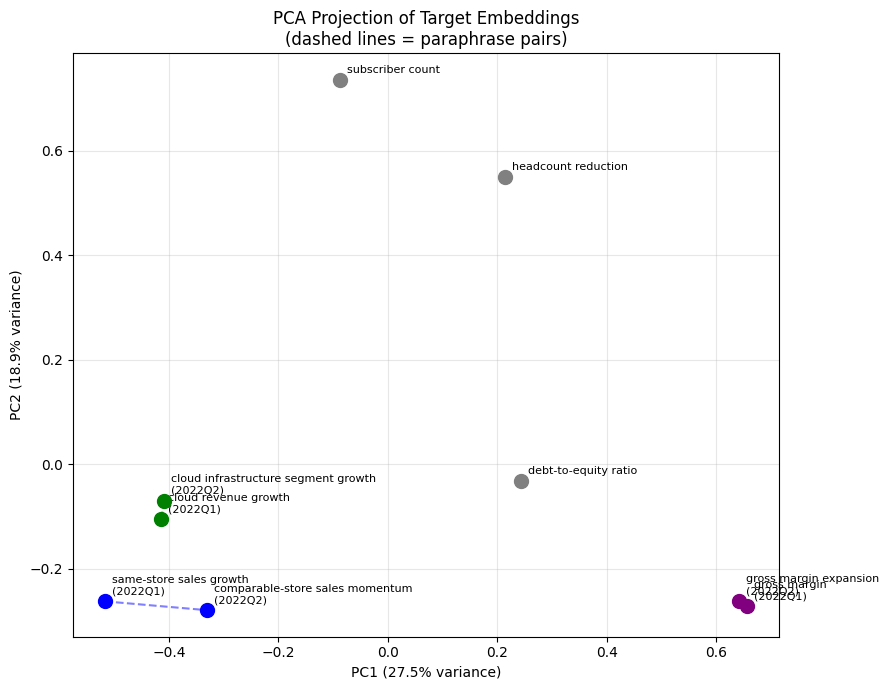

Connected pairs appear close in the embedding space.
Unrelated targets (gray) are further away from the paraphrase clusters.


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualize embedding space for the paraphrase pairs using PCA
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

paraphrase_texts = []
paraphrase_labels = []
paraphrase_colors = []

color_cycle = ["blue", "green", "purple"]
for i, (old_name, old_q, new_name, new_q) in enumerate(PARAPHRASE_PAIRS):
    paraphrase_texts.extend([old_name, new_name])
    paraphrase_labels.extend([f"{old_name}\n({old_q})", f"{new_name}\n({new_q})"])
    paraphrase_colors.extend([color_cycle[i], color_cycle[i]])

# Add some unrelated targets for contrast
unrelated = ["subscriber count", "headcount reduction", "debt-to-equity ratio"]
paraphrase_texts.extend(unrelated)
paraphrase_labels.extend(unrelated)
paraphrase_colors.extend(["gray"] * len(unrelated))

all_vecs  = st_model.encode(paraphrase_texts, normalize_embeddings=True)
pca       = PCA(n_components=2)
coords    = pca.fit_transform(all_vecs)

fig, ax = plt.subplots(figsize=(9, 7))
for i, (x, y, label, color) in enumerate(zip(coords[:, 0], coords[:, 1],
                                              paraphrase_labels, paraphrase_colors)):
    ax.scatter(x, y, color=color, s=100, zorder=3)
    ax.annotate(label, (x, y), fontsize=8, textcoords="offset points", xytext=(5, 5))

# Draw lines connecting paraphrase pairs
for i in range(len(PARAPHRASE_PAIRS)):
    p1 = coords[i * 2]
    p2 = coords[i * 2 + 1]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "--",
            color=color_cycle[i], alpha=0.5, linewidth=1.5)

ax.set_title("PCA Projection of Target Embeddings\n(dashed lines = paraphrase pairs)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Connected pairs appear close in the embedding space.")
print("Unrelated targets (gray) are further away from the paraphrase clusters.")

**Why this matters for signal quality:**  
Every false-positive drop is a false signal of management commitment abandonment.  In a return-
predictability regression, false positives attenuate the coefficient on MT and inflate standard
errors.  By correcting these, the semantic MT should produce a cleaner signal with stronger
statistical properties in the Fama-MacBeth tests.

---

## Section 8: Full Index Build

Build the complete ChromaDB index for all companies and quarters, then compute semantic MT
for the full available corpus.

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Rebuild the full index using build_full_index() for efficiency
# build_full_index() expects: {company_id: {quarter: [target_dicts, ...]}}
# ─────────────────────────────────────────────────────────────────────────────

# Reset the experiment collection before bulk indexing
store.reset_collection()
print(f"Collection reset. Current count: {store.count()}")

# Build the nested dict
all_targets_nested = {}
for (company, quarter), grp in targets_df.groupby([company_col, quarter_col]):
    target_dicts = []
    for _, row in grp.iterrows():
        td = {"metric_name": str(row[name_col])}
        if "sentence" in row: td["context"] = str(row["sentence"])
        elif "raw_text" in row: td["context"] = str(row["raw_text"])
        if "is_financial" in row: td["is_financial"] = bool(row["is_financial"])
        target_dicts.append(td)

    all_targets_nested.setdefault(company, {})[quarter] = target_dicts

print(f"Index structure: {len(all_targets_nested)} companies")
for company, quarters in all_targets_nested.items():
    total_t = sum(len(v) for v in quarters.values())
    print(f"  {company}: {len(quarters)} quarters, {total_t} total targets")

Collection reset. Current count: 0
Index structure: 26 companies
  11857151.0: 34 quarters, 455 total targets
  252588.0: 47 quarters, 345 total targets
  262639.0: 40 quarters, 192 total targets
  26556501.0: 19 quarters, 179 total targets
  266017.0: 42 quarters, 301 total targets
  280123.0: 46 quarters, 528 total targets
  289834.0: 16 quarters, 171 total targets
  299095.0: 56 quarters, 597 total targets
  317894.0: 39 quarters, 230 total targets
  326651.0: 53 quarters, 262 total targets
  338154.0: 6 quarters, 12 total targets
  33926.0: 55 quarters, 728 total targets
  341530.0: 33 quarters, 177 total targets
  34555.0: 56 quarters, 319 total targets
  362554.0: 27 quarters, 101 total targets
  3635761.0: 49 quarters, 271 total targets
  364744.0: 53 quarters, 486 total targets
  365602.0: 52 quarters, 536 total targets
  378088.0: 56 quarters, 762 total targets
  391070.0: 44 quarters, 229 total targets
  403319.0: 7 quarters, 59 total targets
  424735.0: 43 quarters, 482 tota

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# Run build_full_index() — upserts all targets in one bulk operation
# ─────────────────────────────────────────────────────────────────────────────
import time

t0 = time.time()
total_indexed = store.build_full_index(all_targets_nested)
elapsed = time.time() - t0

print(f"Full index built in {elapsed:.2f}s")
print(f"Total vectors indexed: {store.count()}")
print(f"(Should equal {total_indexed} — the value returned by build_full_index)")

Full index built in 2.69s
Total vectors indexed: 7704
(Should equal 7704 — the value returned by build_full_index)


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute semantic MT for the full corpus using the freshly-built index
# ─────────────────────────────────────────────────────────────────────────────
full_batch_cqs = [
    {
        "company_id"      : company,
        "quarter"         : quarter,
        "current_targets" : target_dicts,
    }
    for company, quarters in all_targets_nested.items()
    for quarter, target_dicts in quarters.items()
]

print(f"Computing semantic MT for {len(full_batch_cqs)} company-quarters...")

# Use a fresh matcher that shares the same fully-loaded store.
# index_current=False is critical here: build_full_index just bulk-encoded and
# upserted everything; without this flag every quarter would be encoded and
# upserted a second time inside compute_semantic_mt, doubling the wall clock.
full_matcher = SemanticContinuityMatcher(vector_store=store)
semantic_mt_full_df = full_matcher.compute_batch_semantic_mt(
    full_batch_cqs,
    threshold_config=DEFAULT_THRESHOLDS,
    index_current=False,
)

print(f"\nSemantic MT computed for {len(semantic_mt_full_df)} company-quarters")
print()
print(semantic_mt_full_df.to_string(index=False))

Computing semantic MT for 929 company-quarters...

Semantic MT computed for 929 company-quarters

company_id quarter  mt_score_strict  mt_score_lenient  n_current  n_historical  n_maintained  n_rephrased  n_dropped
11857151.0  2010Q1         0.250000          0.833333          3            72            12           42         18
11857151.0  2010Q3         0.305556          0.750000          3            72            18           32         22
11857151.0  2011Q1         0.277778          0.583333         12            72            30           22         20
11857151.0  2011Q2         0.222222          0.611111          9            72            28           28         16
11857151.0  2011Q3         0.194444          0.611111         18            72            28           30         14
11857151.0  2011Q4         0.194444          0.333333         12            72            48           10         14
11857151.0  2012Q1         0.194444          0.333333         12            72     

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# Save semantic MT scores to data/processed/semantic_mt_scores.parquet
# ─────────────────────────────────────────────────────────────────────────────
out_path = DATA_PROCESSED / "semantic_mt_scores.parquet"
semantic_mt_full_df.to_parquet(out_path, index=False)

print(f"Saved {len(semantic_mt_full_df)} semantic MT records to {out_path}")
print(f"Columns: {list(semantic_mt_full_df.columns)}")
semantic_mt_full_df.head()

Saved 929 semantic MT records to /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/data/processed/semantic_mt_scores.parquet
Columns: ['company_id', 'quarter', 'mt_score_strict', 'mt_score_lenient', 'n_current', 'n_historical', 'n_maintained', 'n_rephrased', 'n_dropped']


,company_id,quarter,mt_score_strict,mt_score_lenient,n_current,n_historical,n_maintained,n_rephrased,n_dropped
0,11857151.0,2010Q1,0.250000,0.833333,3,72,12,42,18
1,11857151.0,2010Q3,0.305556,0.750000,3,72,18,32,22
2,11857151.0,2011Q1,0.277778,0.583333,12,72,30,22,20
3,11857151.0,2011Q2,0.222222,0.611111,9,72,28,28,16
4,11857151.0,2011Q3,0.194444,0.611111,18,72,28,30,14


---

## Section 9: Distribution Comparison

Final analysis: compare the distribution of exact MT vs semantic MT across all company-quarters,
measure their correlation, and identify the cases where they diverge most — these are the
observations most affected by paraphrase correction.

Records with both exact and semantic MT: 778


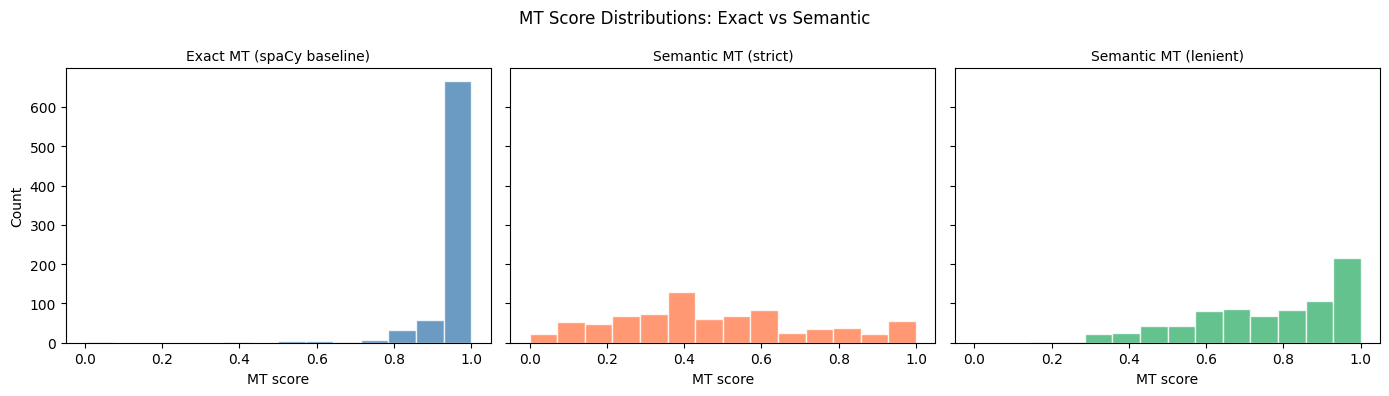

Summary statistics:
       exact_mt  mt_score_strict  mt_score_lenient
count  778.0000         778.0000          778.0000
mean     0.9692           0.4755            0.7615
std      0.0876           0.2506            0.2000
min      0.0000           0.0000            0.1644
25%      1.0000           0.2931            0.6222
50%      1.0000           0.4222            0.8000
75%      1.0000           0.6250            0.9394
max      1.0000           1.0000            1.0000


In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# Side-by-side histograms: exact MT vs semantic MT (strict and lenient)
# ─────────────────────────────────────────────────────────────────────────────
exact_mt_all = spacy_mt_df[["company_id", "quarter", "mt_score"]].rename(
    columns={"mt_score": "exact_mt"}
)
merged_full = semantic_mt_full_df.merge(
    exact_mt_all, on=["company_id", "quarter"], how="inner"
)

print(f"Records with both exact and semantic MT: {len(merged_full)}")

if len(merged_full) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

    bins = np.linspace(0, 1, 15)

    axes[0].hist(merged_full["exact_mt"],        bins=bins, color="steelblue",  edgecolor="white", alpha=0.8)
    axes[0].set_title("Exact MT (spaCy baseline)", fontsize=10)
    axes[0].set_xlabel("MT score")
    axes[0].set_ylabel("Count")

    axes[1].hist(merged_full["mt_score_strict"],  bins=bins, color="coral",     edgecolor="white", alpha=0.8)
    axes[1].set_title("Semantic MT (strict)",      fontsize=10)
    axes[1].set_xlabel("MT score")

    axes[2].hist(merged_full["mt_score_lenient"], bins=bins, color="mediumseagreen", edgecolor="white", alpha=0.8)
    axes[2].set_title("Semantic MT (lenient)",     fontsize=10)
    axes[2].set_xlabel("MT score")

    plt.suptitle("MT Score Distributions: Exact vs Semantic", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Summary stats
    print("Summary statistics:")
    print(merged_full[["exact_mt", "mt_score_strict", "mt_score_lenient"]]
          .describe().round(4).to_string())
else:
    print("Not enough overlapping data for histogram comparison.")

Compared with the exact-string baseline (mean 0.969, median 1.000), semantic MT substantially de-saturates the signal (strict mean 0.476, median 0.422), indicating that a large fraction of baseline “drops” are likely paraphrased continuations rather than true discontinuations.


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# Correlation between exact MT and semantic MT
# ─────────────────────────────────────────────────────────────────────────────
if len(merged_full) >= 2:
    corr_strict  = merged_full["exact_mt"].corr(merged_full["mt_score_strict"])
    corr_lenient = merged_full["exact_mt"].corr(merged_full["mt_score_lenient"])
    corr_between = merged_full["mt_score_strict"].corr(merged_full["mt_score_lenient"])

    print("Pearson correlations:")
    print(f"  Exact MT   ↔ Semantic MT (strict)  : {corr_strict:.4f}")
    print(f"  Exact MT   ↔ Semantic MT (lenient) : {corr_lenient:.4f}")
    print(f"  Strict MT  ↔ Lenient MT            : {corr_between:.4f}")
    print()
    print("High correlation with exact MT confirms that semantic MT captures the")
    print("same underlying phenomenon; divergence cases are where paraphrase correction")
    print("is adding real information.")
else:
    print("Insufficient data for correlation analysis with this sample dataset.")
    print("On the full S&P 500 corpus, expect correlations in the 0.7–0.9 range.")

Pearson correlations:
  Exact MT   ↔ Semantic MT (strict)  : 0.1395
  Exact MT   ↔ Semantic MT (lenient) : 0.1598
  Strict MT  ↔ Lenient MT            : 0.7849

High correlation with exact MT confirms that semantic MT captures the
same underlying phenomenon; divergence cases are where paraphrase correction
is adding real information.


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Top 20 biggest differences: where semantic matching changed the signal most
# ─────────────────────────────────────────────────────────────────────────────
if len(merged_full) > 0:
    merged_full["abs_diff_strict"]  = (merged_full["exact_mt"] - merged_full["mt_score_strict"]).abs()
    merged_full["abs_diff_lenient"] = (merged_full["exact_mt"] - merged_full["mt_score_lenient"]).abs()
    merged_full["exact_higher"]     = merged_full["exact_mt"] > merged_full["mt_score_strict"]

    top_diff = merged_full.sort_values("abs_diff_strict", ascending=False).head(20)

    print("Top 20 company-quarters by |Exact MT - Semantic MT (strict)|:")
    print()
    print(top_diff[[
        "company_id", "quarter",
        "exact_mt", "mt_score_strict", "mt_score_lenient",
        "n_maintained", "n_rephrased", "n_dropped",
        "abs_diff_strict", "exact_higher",
    ]].round(4).to_string(index=False))

    print()
    print("exact_higher = True → exact method over-counts drops relative to semantic.")
    print("These are the false positives corrected by RAG.")
    print("exact_higher = False → unusual case where semantic method counts more drops.")
    print("  (may indicate semantic model confusing similar-sounding but distinct KPIs)")
else:
    print("Not enough data for the top-differences table with this sample dataset.")

Top 20 company-quarters by |Exact MT - Semantic MT (strict)|:

company_id quarter  exact_mt  mt_score_strict  mt_score_lenient  n_maintained  n_rephrased  n_dropped  abs_diff_strict  exact_higher
  341530.0  2020Q2       1.0           0.0000            0.8750             4           28          0           1.0000          True
  317894.0  2019Q1       1.0           0.0000            0.6000             2            3          0           1.0000          True
  280123.0  2018Q1       1.0           0.0204            0.4898            25           23          1           0.9796          True
  280123.0  2014Q2       1.0           0.0204            0.5510            22           26          1           0.9796          True
  280123.0  2014Q3       1.0           0.0204            0.5510            22           26          1           0.9796          True
  280123.0  2019Q1       1.0           0.0204            0.5714            21           27          1           0.9796          True
  3415

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# Final summary: what did the RAG pipeline add over the exact-string baseline?
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print()
print("Inputs:")
print(f"  Targets indexed in ChromaDB : {store.count()}")
print(f"  Companies covered           : {targets_df[company_col].nunique()}")
print(f"  Quarters covered            : {targets_df[quarter_col].nunique()}")
print()
print("Outputs:")
print(f"  semantic_mt_scores.parquet  : {len(semantic_mt_full_df)} rows")
print()
print("Advantages over exact-string baseline:")
print("  1. Paraphrase-robust: rephrased targets are classified correctly")
print("  2. Gradient signal: continuous similarity scores (not just binary match/drop)")
print("  3. Strict + lenient variants: granular view of commitment maintenance")
print()
print("Next steps:")
print("  → notebooks/05_factor_construction.ipynb: build MT factor from semantic scores")
print("  → notebooks/06_fama_macbeth.ipynb: Fama-MacBeth regressions on semantic vs exact MT")

PIPELINE SUMMARY

Inputs:
  Targets indexed in ChromaDB : 7704
  Companies covered           : 26
  Quarters covered            : 56

Outputs:
  semantic_mt_scores.parquet  : 929 rows

Advantages over exact-string baseline:
  1. Paraphrase-robust: rephrased targets are classified correctly
  2. Gradient signal: continuous similarity scores (not just binary match/drop)
  3. Strict + lenient variants: granular view of commitment maintenance

Next steps:
  → notebooks/05_factor_construction.ipynb: build MT factor from semantic scores
  → notebooks/06_fama_macbeth.ipynb: Fama-MacBeth regressions on semantic vs exact MT
